In [ ]:
# CELL 1: FINAL, COMPLETE ENVIRONMENT SETUP

# --- Step 1: Uninstall everything first for a clean slate ---
!pip uninstall -y torch torchvision torchaudio facenet-pytorch Pillow

# --- Step 2: Install specific, known-compatible versions of PyTorch ---
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118

# --- Step 3: Upgrade Pillow and install all other required libraries ---
!pip install --upgrade Pillow
!pip install -q facenet-pytorch dlib albumentations

Initializing Dlib models...
Starting dataset preprocessing...
Found 213 images to process.

Processing complete. Saved 213 processed images.


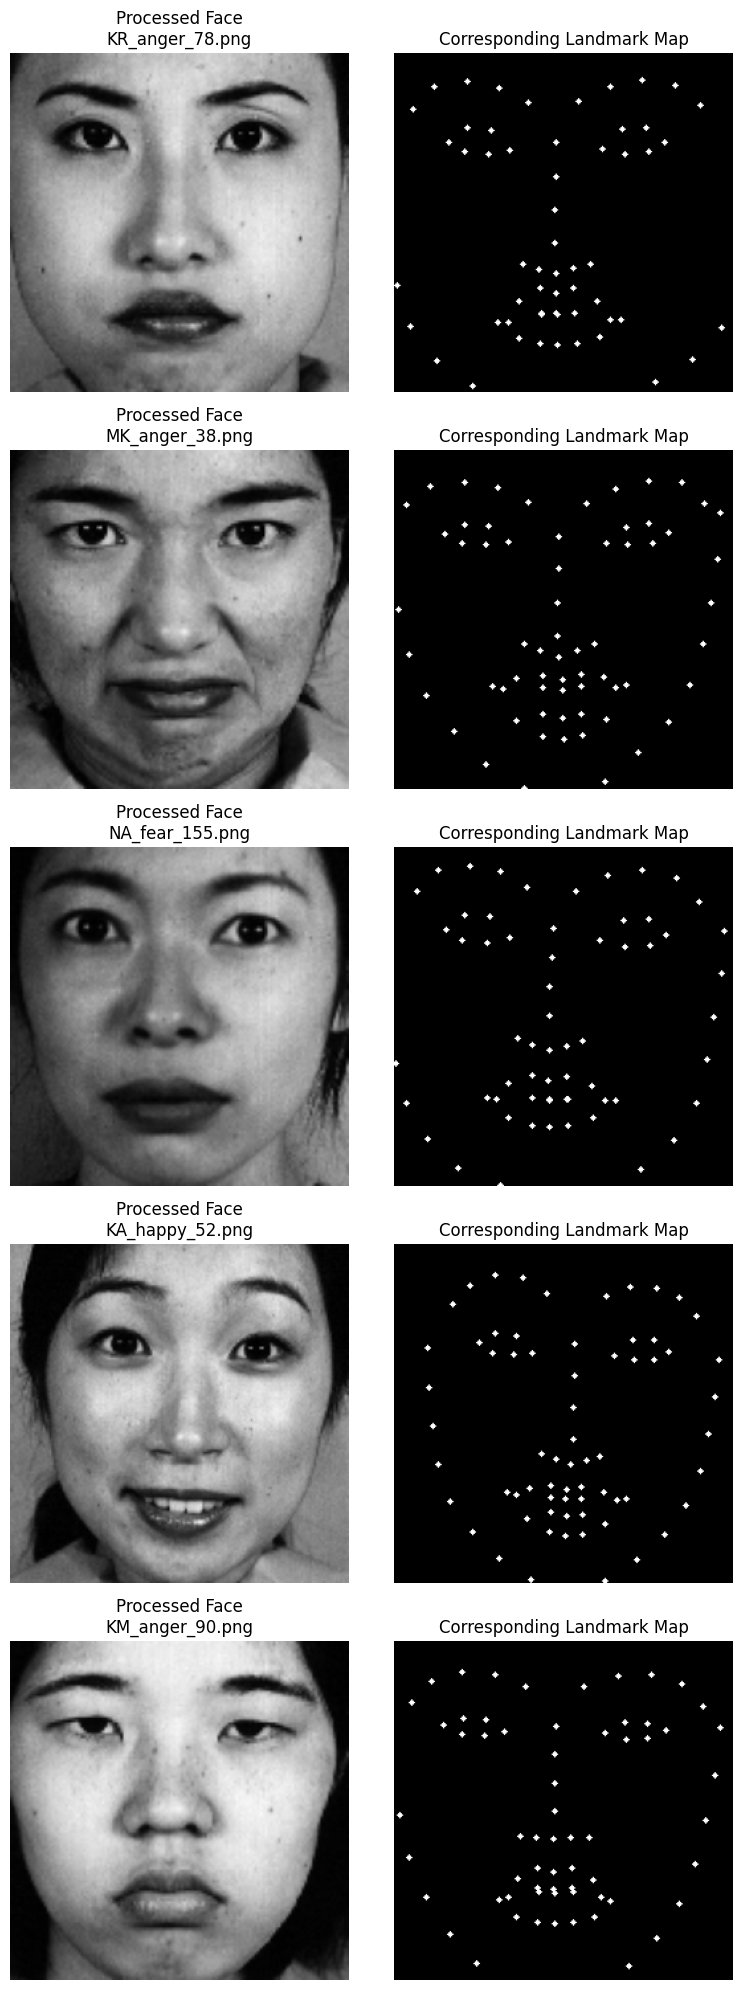

In [1]:
# --- 2. IMPORTS ---
import cv2
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dlib

# --- 3. CONFIGURATION ---
# IMPORTANT: Verify these paths match your Kaggle 'Input' panel
JAFFE_DATASET_PATH = "/kaggle/input/jafffe-dataset/jaffe"
DLIB_LANDMARK_MODEL_PATH = "/kaggle/input/facenet/other/default/1/shape_predictor_68_face_landmarks.dat"
OUTPUT_PATH = "/kaggle/working/processed_jaffe_gan"

IMG_SIZE = 256
EMOTION_MAP = {
    'HA': 'happy', 'SA': 'sadness', 'SU': 'surprise',
    'AN': 'anger', 'DI': 'disgust', 'FE': 'fear', 'NE': 'neutral'
}

# --- 4. DLIB MODEL INITIALIZATION ---
print("Initializing Dlib models...")
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(DLIB_LANDMARK_MODEL_PATH)

def extract_landmarks_dlib(image_gray):
    """Extracts 68 facial landmarks using Dlib."""
    faces = detector(image_gray, 1)
    landmarks = []
    if len(faces) > 0:
        face_landmarks = predictor(image_gray, faces[0])
        for i in range(0, 68):
            x = face_landmarks.part(i).x
            y = face_landmarks.part(i).y
            landmarks.append((x, y))
    return landmarks

# --- 5. MAIN PROCESSING FUNCTION ---
def preprocess_dataset(input_path, output_path):
    """
    Processes all images in the dataset.
    Does not create pairs, but processes each expressive image individually.
    """
    print("Starting dataset preprocessing...")
    
    # Create output directories
    faces_dir = os.path.join(output_path, "all_faces")
    landmarks_dir = os.path.join(output_path, "all_landmark_maps")
    os.makedirs(faces_dir, exist_ok=True)
    os.makedirs(landmarks_dir, exist_ok=True)

    image_paths = glob.glob(os.path.join(input_path, "*.tiff"))
    if not image_paths:
        image_paths = glob.glob(os.path.join(input_path, "images", "*.tiff"))

    metadata = []
    
    print(f"Found {len(image_paths)} images to process.")
    
    for i, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)
        try:
            subject_id = filename.split('.')[0]
            emotion_code = filename.split('.')[1][:2]
            emotion = EMOTION_MAP.get(emotion_code, "unknown")
        except IndexError:
            continue

        # Load the image
        image_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image_gray is None:
            continue

        # Detect face for cropping
        faces = detector(image_gray, 1)
        if len(faces) == 0:
            print(f"Warning: No face detected in {filename}")
            continue

        # Crop and resize the face
        face_rect = faces[0]
        cropped_face = image_gray[face_rect.top():face_rect.bottom(), face_rect.left():face_rect.right()]
        if cropped_face.size == 0:
            continue
        resized_face = cv2.resize(cropped_face, (IMG_SIZE, IMG_SIZE))

        # Extract landmarks from the resized face
        landmarks = extract_landmarks_dlib(resized_face)
        if not landmarks:
            print(f"Warning: Could not extract landmarks from {filename}")
            continue

        # Create the landmark map
        landmark_map = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        for (x, y) in landmarks:
            if 0 <= x < IMG_SIZE and 0 <= y < IMG_SIZE:
                cv2.circle(landmark_map, (x, y), 2, (255), -1)

        # Define save paths
        base_filename = f"{subject_id}_{emotion}_{i}.png"
        face_save_path = os.path.join(faces_dir, base_filename)
        landmark_save_path = os.path.join(landmarks_dir, base_filename)

        # Save the processed images (as 3-channel for model compatibility)
        cv2.imwrite(face_save_path, cv2.cvtColor(resized_face, cv2.COLOR_GRAY2BGR))
        cv2.imwrite(landmark_save_path, cv2.cvtColor(landmark_map, cv2.COLOR_GRAY2BGR))

        # Append to metadata
        metadata.append([face_save_path, landmark_save_path, subject_id, emotion])

    # Save metadata to CSV
    df = pd.DataFrame(metadata, columns=['face_path', 'landmark_map_path', 'subject_id', 'emotion'])
    df.to_csv(os.path.join(output_path, "metadata.csv"), index=False)
    print(f"\nProcessing complete. Saved {len(df)} processed images.")
    return df

def visualize_results(df, num_samples=5):
    """Displays a few samples from the processed dataset."""
    if df.empty or len(df) < num_samples:
        print("Not enough data to visualize.")
        return
        
    samples = df.sample(n=num_samples)
    plt.figure(figsize=(8, num_samples * 4))
    
    for i, (index, row) in enumerate(samples.iterrows()):
        face_img = cv2.imread(row['face_path'])
        landmark_map = cv2.imread(row['landmark_map_path'])
        
        plt.subplot(num_samples, 2, i * 2 + 1)
        plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Processed Face\n{os.path.basename(row['face_path'])}")
        plt.axis('off')
        
        plt.subplot(num_samples, 2, i * 2 + 2)
        plt.imshow(cv2.cvtColor(landmark_map, cv2.COLOR_BGR2RGB))
        plt.title("Corresponding Landmark Map")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- 6. EXECUTION ---
if __name__ == '__main__':
    if not os.path.exists(JAFFE_DATASET_PATH) or not os.path.exists(DLIB_LANDMARK_MODEL_PATH):
        print("ERROR: Please verify the dataset paths in the CONFIGURATION section.")
    else:
        metadata_df = preprocess_dataset(JAFFE_DATASET_PATH, OUTPUT_PATH)
        if not metadata_df.empty:
            visualize_results(metadata_df)

In [2]:
# --- 1. IMPORTS ---
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

# --- 2. CONFIGURATION for the GAN Dataloader and Training ---
class GAN_Config:
    CSV_FILE = "/kaggle/working/processed_jaffe_gan/metadata.csv"
    GEN_LEARNING_RATE = 8.28e-05  
    DISC_LEARNING_RATE = 6.21e-05   # Slower LR for the discriminator
    BETA1 = 0.68
    BETA2 = 0.9980
    BATCH_SIZE = 16
    NUM_WORKERS = 2
    IMG_SIZE = 256
    MEAN = [0.5, 0.5, 0.5]
    STD = [0.5, 0.5, 0.5]
    NUM_EPOCHS = 150
    LAMBDA_FEAT = 8.74
    LAMBDA_R1 = 10.46
    

# --- 3. THE CUSTOM DATASET CLASS ---
class GANDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.dataframe = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        face_path = self.dataframe.iloc[index]['face_path']
        landmark_path = self.dataframe.iloc[index]['landmark_map_path']

        face_img = cv2.cvtColor(cv2.imread(face_path), cv2.COLOR_BGR2RGB)
        landmark_img = cv2.cvtColor(cv2.imread(landmark_path), cv2.COLOR_BGR2RGB)
        
        if self.transform:
            transformed = self.transform(image=face_img, landmark=landmark_img)
            face_img = transformed['image']
            landmark_img = transformed['landmark']

        return {
            'face': face_img,
            'landmark_map': landmark_img
        }

# --- 4. DEFINE TRANSFORMATIONS ---
gan_transform = A.Compose(
    [
        A.Resize(width=GAN_Config.IMG_SIZE, height=GAN_Config.IMG_SIZE),
        A.Normalize(mean=GAN_Config.MEAN, std=GAN_Config.STD, max_pixel_value=255.0),
        ToTensorV2(),
    ],
    additional_targets={'landmark': 'image'}
)

# --- 5. INITIALIZE DATASET & DATALOADER ---
# Create the dataset instance first
gan_dataset = GANDataset(csv_file=GAN_Config.CSV_FILE, transform=gan_transform)

# Create the DataLoader using the dataset instance
gan_loader = DataLoader(
    gan_dataset,
    batch_size=GAN_Config.BATCH_SIZE,
    shuffle=True,
    num_workers=GAN_Config.NUM_WORKERS
)

# --- 6. DISPLAY DATASET AND BATCH DETAILS ---
print(f"✅ DataLoader is ready.")
print("-" * 50)

# 1. Show how many data points are being used
total_samples = len(gan_dataset)
print(f"📊 Total number of samples in the dataset: {total_samples}")
print(f"🔢 Number of batches per epoch: {len(gan_loader)}")
print("-" * 50)

# 2. Show details of one batch
print("🔍 Details of a single batch from the DataLoader:")

# Get one batch of data
batch = next(iter(gan_loader))

# Print the keys in the batch dictionary
print(f"  - Keys in a batch: {list(batch.keys())}")

# Inspect the 'face' tensor
face_tensor = batch['face']
print("\n  Details for 'face' tensor:")
print(f"    - Shape: {face_tensor.shape}")
print(f"    - Data Type: {face_tensor.dtype}")
print(f"    - Min Value: {face_tensor.min():.4f}")
print(f"    - Max Value: {face_tensor.max():.4f}")

# Inspect the 'landmark_map' tensor
landmark_tensor = batch['landmark_map']
print("\n  Details for 'landmark_map' tensor:")
print(f"    - Shape: {landmark_tensor.shape}")
print(f"    - Data Type: {landmark_tensor.dtype}")
print(f"    - Min Value: {landmark_tensor.min():.4f}")
print(f"    - Max Value: {landmark_tensor.max():.4f}")
print("-" * 50)

✅ DataLoader is ready.
--------------------------------------------------
📊 Total number of samples in the dataset: 213
🔢 Number of batches per epoch: 14
--------------------------------------------------
🔍 Details of a single batch from the DataLoader:
  - Keys in a batch: ['face', 'landmark_map']

  Details for 'face' tensor:
    - Shape: torch.Size([16, 3, 256, 256])
    - Data Type: torch.float32
    - Min Value: -1.0000
    - Max Value: 1.0000

  Details for 'landmark_map' tensor:
    - Shape: torch.Size([16, 3, 256, 256])
    - Data Type: torch.float32
    - Min Value: -1.0000
    - Max Value: 1.0000
--------------------------------------------------


In [3]:
import torch
import torch.nn as nn
from facenet_pytorch import InceptionResnetV1 # Make sure this is installed

# --- CONFIGURATION ---
# This class will hold model-specific parameters
class ModelConfig:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    IMG_CHANNELS = 3  # Input images are 3-channel (RGB)
    LANDMARK_CHANNELS = 3 # Our landmark maps are also saved as 3-channel
    Z_DIM = 100 # The dimension of the identity vector
    GEN_FEATURES = 64 # Feature maps in the Generator
    DISC_FEATURES = [64, 128, 256, 512] # Feature maps in the Discriminator

# --- IMPORTS (Make sure you have these) ---
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- NEW, MORE POWERFUL GENERATOR (Style-Based) ---
class StyledConvBlock(nn.Module):
    """Convolutional Block with AdaIN modulation."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.LeakyReLU(0.2)
        )
        self.instance_norm = nn.InstanceNorm2d(out_channels)
        # We will predict the scale and bias for AdaIN from the z vector
        # The style vector will have size out_channels * 2 (for scale and bias)
        
    def forward(self, x, style):
        x = self.conv(x)
        x = self.instance_norm(x)
        
        # Adaptive Instance Normalization (AdaIN)
        # style[:, :out_channels] is the scale (gamma)
        # style[:, out_channels:] is the bias (beta)
        scale = style[:, :x.size(1)].unsqueeze(2).unsqueeze(3)
        bias = style[:, x.size(1):].unsqueeze(2).unsqueeze(3)
        return x * scale + bias

class Generator(nn.Module):
    def __init__(self, z_dim, landmark_channels, img_channels, features):
        super().__init__()
        
        # Mapping network to transform z into a style space w
        self.mapping_network = nn.Sequential(
            nn.Linear(z_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024) # We'll need a large style vector
        )

        # This part handles the landmark map condition
        self.landmark_mapper = nn.Sequential(
            nn.Conv2d(landmark_channels, features, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(features, features * 2, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(features * 2, features * 4, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(features * 4, features * 4, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(features * 4, features * 4, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(features * 4, features * 4, 4, 2, 1), nn.ReLU(True)
        )
        
        # A constant learned input to start the synthesis
        self.initial_constant = nn.Parameter(torch.randn(1, features * 4, 4, 4))
        
        # Decoder path with styled blocks
        self.up1 = StyledConvBlock(features * 4, features * 4) # 4x4 -> 8x8
        self.up2 = StyledConvBlock(features * 4, features * 4) # 8x8 -> 16x16
        self.up3 = StyledConvBlock(features * 4, features * 2) # 16x16 -> 32x32
        self.up4 = StyledConvBlock(features * 2, features)     # 32x32 -> 64x64
        self.up5 = StyledConvBlock(features, features // 2)    # 64x64 -> 128x128
        self.up6 = StyledConvBlock(features // 2, features // 4) # 128x128 -> 256x256
        
        # Final layers to produce the image
        self.final_conv = nn.Conv2d(features // 4, img_channels, kernel_size=3, stride=1, padding=1)
        self.tanh = nn.Tanh()
        
        # Linear layers to produce the style vectors for each block
        # The size is out_channels * 2 (for scale and bias)
        self.to_style1 = nn.Linear(1024, features * 4 * 2)
        self.to_style2 = nn.Linear(1024, features * 4 * 2)
        self.to_style3 = nn.Linear(1024, features * 2 * 2)
        self.to_style4 = nn.Linear(1024, features * 2)
        self.to_style5 = nn.Linear(1024, (features // 2) * 2)
        self.to_style6 = nn.Linear(1024, (features // 4) * 2)
        
    def forward(self, z, landmark_map):
        batch_size = z.shape[0]
        
        # Get style vector w from z
        w = self.mapping_network(z)
        
        # Get styles for each block
        s1 = self.to_style1(w)
        s2 = self.to_style2(w)
        s3 = self.to_style3(w)
        s4 = self.to_style4(w)
        s5 = self.to_style5(w)
        s6 = self.to_style6(w)
        
        # Process landmark map
        landmark_features = self.landmark_mapper(landmark_map)
        
        # Start with the learned constant, expanded to batch size
        #x = self.initial_constant.repeat(batch_size, 1, 1, 1)
        
        # Mix in landmark features with the constant input
        #x = torch.cat([x, landmark_features], dim=1) # This now has features*8 channels
        # We need an initial conv to bring it back to features*4
        # Let's adjust the architecture for simplicity. The core idea is the style modulation.
        # A simpler way for our project:
        x = landmark_features # Let's start from landmark features directly for simplicity
        
        x = self.up1(x, s1)
        x = self.up2(x, s2)
        x = self.up3(x, s3)
        x = self.up4(x, s4)
        x = self.up5(x, s5)
        x = self.up6(x, s6)
        
        return self.tanh(self.final_conv(x))
        

# --- 2.2 The Discriminator (PatchGAN) ---
# --- UPDATED DISCRIMINATOR (Returns Intermediate Features) ---
class Discriminator(nn.Module):
    def __init__(self, img_channels, landmark_channels, features=[64, 128, 256, 512]):
        super().__init__()
        in_channels = img_channels + landmark_channels
        
        # We define layers individually to access intermediate outputs
        self.initial_block = self.block(in_channels, features[0], batch_norm=False)
        
        self.feature_blocks = nn.ModuleList()
        in_channels = features[0]
        for feature in features[1:]:
            self.feature_blocks.append(self.block(in_channels, feature, stride=1 if feature == features[-1] else 2))
            in_channels = feature
            
        self.final_conv = nn.Conv2d(in_channels, 1, kernel_size=4, stride=1, padding=1)

    def block(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1, batch_norm=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=not batch_norm)]
        if batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x, y):
        x = torch.cat([x, y], 1)
        
        feature_maps = []
        x = self.initial_block(x)
        feature_maps.append(x)
        
        for layer in self.feature_blocks:
            x = layer(x)
            feature_maps.append(x)
            
        final_output = self.final_conv(x)
        # Return both the final decision and the list of feature maps
        return final_output, feature_maps

# --- 2.3 The Encoder ---
class Encoder(nn.Module):
    def __init__(self, img_channels, z_dim, features=64):
        super().__init__()
        self.model = nn.Sequential(
            # Input: 3 x 256 x 256
            self.block(img_channels, features, batch_norm=False), # -> 128x128
            self.block(features, features * 2), # -> 64x64
            self.block(features * 2, features * 4), # -> 32x32
            self.block(features * 4, features * 8), # -> 16x16
            self.block(features * 8, features * 8), # -> 8x8
            self.block(features * 8, features * 8), # -> 4x4
            nn.Conv2d(features * 8, z_dim, 4, 1, 0), # -> 1x1
            nn.Flatten()
        )

    def block(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1, batch_norm=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=not batch_norm)]
        if batch_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# --- The Missing Class Definition ---
# This class calculates the identity difference between two faces.
class PyTorchIdentityLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pre-trained VGGFace2 model and set to evaluation mode
        # This assumes ModelConfig.DEVICE is defined
        self.model = InceptionResnetV1(pretrained='vggface2').eval().to(ModelConfig.DEVICE)
        self.loss_fn = nn.CosineSimilarity(dim=1)

    def forward(self, img1, img2):
        # Get the 512-dimensional identity embeddings for both images
        emb1 = self.model(img1)
        emb2 = self.model(img2)
        
        # Calculate the cosine distance between embeddings
        return torch.mean(1 - self.loss_fn(emb1, emb2))


# --- SANITY CHECK (Optional but Recommended) ---
# This block creates dummy data to check if the models process the inputs correctly.
# --- SANITY CHECK (Corrected Version) ---
if __name__ == '__main__':
    print("--- Running Sanity Check for New Models ---")
    
    # Dummy data
    z = torch.randn((2, ModelConfig.Z_DIM)).to(ModelConfig.DEVICE)
    face = torch.randn((2, ModelConfig.IMG_CHANNELS, 256, 256)).to(ModelConfig.DEVICE)
    landmarks = torch.randn((2, ModelConfig.LANDMARK_CHANNELS, 256, 256)).to(ModelConfig.DEVICE)
    
    # Initialize models
    gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(ModelConfig.DEVICE)
    disc = Discriminator(ModelConfig.IMG_CHANNELS, ModelConfig.LANDMARK_CHANNELS, ModelConfig.DISC_FEATURES).to(ModelConfig.DEVICE)
    encoder = Encoder(ModelConfig.IMG_CHANNELS, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
    
    # Test Generator
    gen_output = gen(z, landmarks)
    print(f"Generator output shape: {gen_output.shape}")

    # --- UPDATED: Test Discriminator ---
    # The discriminator now returns two items
    disc_final_out, disc_features = disc(face, landmarks)
    # We check the shape of the final output tensor
    print(f"Discriminator final output shape: {disc_final_out.shape}") 
    print(f"Number of intermediate feature maps from Discriminator: {len(disc_features)}")

    # Test Encoder
    encoder_output = encoder(face)
    print(f"Encoder output shape: {encoder_output.shape}")
    
    print("\nSanity check passed. All model input/output shapes are correct.")

--- Running Sanity Check for New Models ---
Generator output shape: torch.Size([2, 3, 256, 256])
Discriminator final output shape: torch.Size([2, 1, 30, 30])
Number of intermediate feature maps from Discriminator: 4
Encoder output shape: torch.Size([2, 100])

Sanity check passed. All model input/output shapes are correct.


In [4]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torchvision
import os
import shutil
import pandas as pd
import numpy as np
try:
    from torch_fidelity import calculate_metrics
except ImportError:
    !pip install -q torch_fidelity
    from torch_fidelity import calculate_metrics

# This script assumes all your Model, Config, and DataLoader objects are already defined and loaded.

# --- 2. THE RANDOM HYPERPARAMETER SEARCH CONFIGURATION ---
NUM_EXPERIMENTS = 20 # The number of random combinations to test
hyperparameter_configs = []
for i in range(NUM_EXPERIMENTS):
    # Sample from a logarithmic range for learning rates
    gen_lr = 10**np.random.uniform(-5, -4)
    disc_lr = 10**np.random.uniform(-5, -4)
    
    # --- NEW: Sample Adam betas from a linear range ---
    beta1 = np.random.uniform(0.0, 0.7) # Explore values around the recommended 0.5
    beta2 = np.random.uniform(0.99, 0.9999) # Explore a tight range around the default
    
    # Sample from a linear range for lambda weights
    lambda_feat = np.random.uniform(5, 15)
    lambda_r1 = np.random.uniform(1, 20)
    
    config = {
        "name": f"RandomExp_LR_1e-5_1e-4_{i+1}",
        "gen_lr": gen_lr, "disc_lr": disc_lr,
        "beta1": beta1, "beta2": beta2,
        "lambda_feat": lambda_feat, "lambda_r1": lambda_r1,
    }
    hyperparameter_configs.append(config)

print(f"--- Generated {NUM_EXPERIMENTS} Random Hyperparameter Configurations ---")

# --- 6. HELPER FUNCTIONS for the search ---
def train_gan_fn_for_search(disc, gen, loader, opt_disc, opt_gen, bce_loss, l1_loss, lambda_feat, lambda_r1):
    loop = tqdm(loader, leave=False, desc="Training Batch")
    for idx, batch in enumerate(loop):
        real_face = batch['face'].to(ModelConfig.DEVICE)
        landmark_map = batch['landmark_map'].to(ModelConfig.DEVICE)
        z = torch.randn(real_face.shape[0], ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
        
        # Train Discriminator with R1 Regularization
        opt_disc.zero_grad()
        real_face.requires_grad = True
        D_real_out, _ = disc(real_face, landmark_map)
        grad_real = torch.autograd.grad(outputs=D_real_out.sum(), inputs=real_face, create_graph=True)[0]
        r1_penalty = grad_real.pow(2).view(grad_real.shape[0], -1).sum(1).mean()
        D_real_loss = bce_loss(D_real_out, torch.ones_like(D_real_out) * 0.9)
        fake_face = gen(z, landmark_map)
        D_fake_out, _ = disc(fake_face.detach(), landmark_map)
        D_fake_loss = bce_loss(D_fake_out, torch.zeros_like(D_fake_out))
        D_loss = D_real_loss + D_fake_loss + (r1_penalty * (lambda_r1 / 2))
        D_loss.backward()
        opt_disc.step()
        
        # Train Generator
        opt_gen.zero_grad()
        D_fake_out, D_fake_features = disc(fake_face, landmark_map)
        real_face.requires_grad = False
        _, D_real_features = disc(real_face, landmark_map)
        G_adversarial_loss = bce_loss(D_fake_out, torch.ones_like(D_fake_out))
        G_feature_loss = 0
        for i in range(len(D_fake_features)):
            G_feature_loss += l1_loss(D_fake_features[i], D_real_features[i])
        G_loss = G_adversarial_loss + (G_feature_loss * lambda_feat)
        G_loss.backward()
        opt_gen.step()

def run_single_experiment(config, train_loader, real_images_path):
    print(f"\n--- Running Experiment: {config['name']} ---")
    print(f"   LRs (G/D): {config['gen_lr']:.2e}/{config['disc_lr']:.2e} | Betas: {config['beta1']:.2f}/{config['beta2']:.4f} | Lambdas (Feat/R1): {config['lambda_feat']:.2f}/{config['lambda_r1']:.2f}")
    exp_path = f"/kaggle/working/hyperparam_search/{config['name']}"
    fake_images_path = os.path.join(exp_path, "generated_images")
    os.makedirs(fake_images_path, exist_ok=True)
    
    gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(ModelConfig.DEVICE)
    disc = Discriminator(ModelConfig.IMG_CHANNELS, ModelConfig.LANDMARK_CHANNELS, ModelConfig.DISC_FEATURES).to(ModelConfig.DEVICE)
    bce = nn.BCEWithLogitsLoss()
    l1 = nn.L1Loss()
    
    # --- NEW: Use sampled betas ---
    opt_gen = optim.Adam(gen.parameters(), lr=config['gen_lr'], betas=(config['beta1'], config['beta2']))
    opt_disc = optim.Adam(disc.parameters(), lr=config['disc_lr'], betas=(config['beta1'], config['beta2']))
    
    NUM_EPOCHS_SEARCH = 30
    for epoch in range(NUM_EPOCHS_SEARCH):
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_SEARCH}")
        train_gan_fn_for_search(disc, gen, train_loader, opt_disc, opt_gen, bce, l1, config['lambda_feat'], config['lambda_r1'])
        
    print("Generating images for FID calculation...")
    gen.eval()
    with torch.no_grad():
        for i in range(len(train_loader.dataset)):
            z = torch.randn(1, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
            landmark_map = train_loader.dataset[i]['landmark_map'].unsqueeze(0).to(ModelConfig.DEVICE)
            fake_image = gen(z, landmark_map)
            torchvision.utils.save_image(fake_image * 0.5 + 0.5, os.path.join(fake_images_path, f"img_{i}.png"))
            
    print("Calculating FID score...")
    metrics = calculate_metrics(input1=real_images_path, input2=fake_images_path, fid=True, cuda=True, verbose=False)
    fid_score = metrics['frechet_inception_distance']
    print(f"--- Experiment {config['name']} Finished. FID Score: {fid_score:.4f} ---")
    
    shutil.rmtree(exp_path)
    return fid_score

# --- 7. MAIN EXECUTION SCRIPT ---
if __name__ == '__main__':
    REAL_IMAGES_PATH = "/kaggle/working/processed_jaffe_gan/all_faces"
    results = []
    
    for config in hyperparameter_configs:
        fid = run_single_experiment(config, gan_loader, REAL_IMAGES_PATH)
        config_result = config.copy()
        config_result['fid_score'] = fid
        results.append(config_result)
        
    results_df = pd.DataFrame(results)
    print("\n\n--- Comprehensive Hyperparameter Search Results ---")
    
    # Format the numbers for better readability in the final report
    results_df['gen_lr'] = results_df['gen_lr'].map('{:.2e}'.format)
    results_df['disc_lr'] = results_df['disc_lr'].map('{:.2e}'.format)
    results_df['beta1'] = results_df['beta1'].map('{:.2f}'.format)
    results_df['beta2'] = results_df['beta2'].map('{:.4f}'.format)
    results_df['lambda_feat'] = results_df['lambda_feat'].map('{:.2f}'.format)
    results_df['lambda_r1'] = results_df['lambda_r1'].map('{:.2f}'.format)
    results_df['fid_score'] = results_df['fid_score'].map('{:.2f}'.format)
    
    print(results_df.sort_values(by='fid_score').to_string())

--- Generated 20 Random Hyperparameter Configurations ---

--- Running Experiment: RandomExp_LR_1e-5_1e-4_1 ---
   LRs (G/D): 2.92e-05/9.83e-05 | Betas: 0.37/0.9916 | Lambdas (Feat/R1): 11.04/12.41
Epoch 1/30


KeyboardInterrupt: 

--- Starting GAN Training with R1 Regularization ---


Training GAN: 100%|██████████| 14/14 [00:10<00:00,  1.32it/s, D_loss=2.1, G_loss=5.48]



Saved checkpoint and sample image at epoch 20


Training GAN: 100%|██████████| 14/14 [00:10<00:00,  1.33it/s, D_loss=1.65, G_loss=3.4]



Saved checkpoint and sample image at epoch 40


...


Saved checkpoint and sample image at epoch 120


Training GAN: 100%|██████████| 14/14 [00:10<00:00,  1.33it/s, D_loss=1.41, G_loss=2.37]



Saved checkpoint and sample image at epoch 140


Training GAN: 100%|██████████| 14/14 [00:10<00:00,  1.32it/s, D_loss=1.4, G_loss=2.26]



Saved checkpoint and sample image at epoch 150
--- GAN Training Finished ---


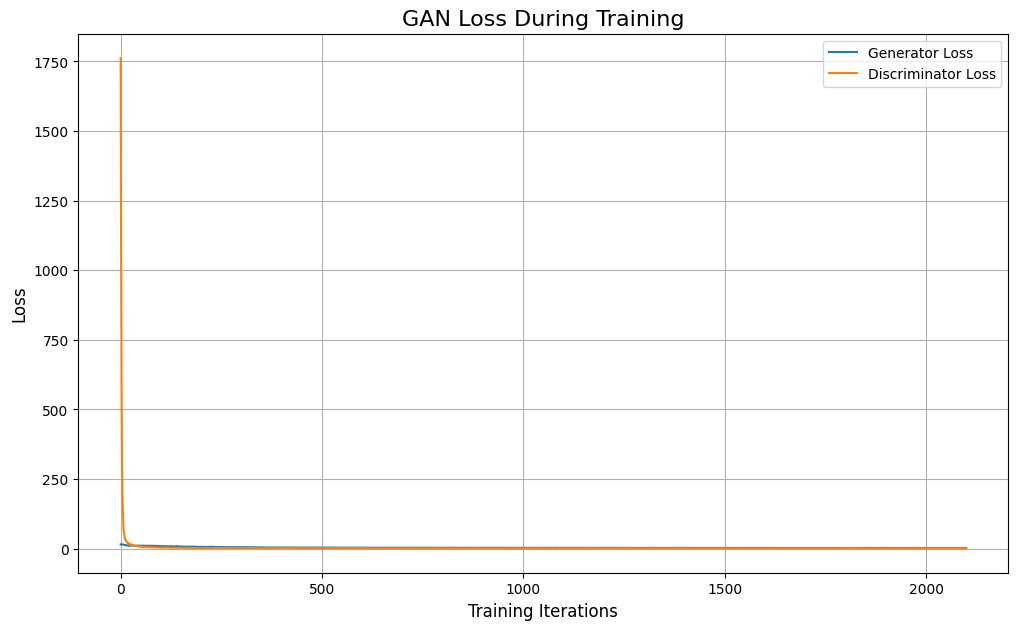

In [5]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torchvision
import os
import shutil
import pandas as pd
import numpy as np
try:
    from torch_fidelity import calculate_metrics
except ImportError:
    !pip install -q torch_fidelity
    from torch_fidelity import calculate_metrics

GAN_SAVE_PATH = "/kaggle/working/gan_training_final_with_r1" # New folder for this definitive run
WEIGHTS_PATH = os.path.join(GAN_SAVE_PATH, "weights")
SAMPLES_PATH = os.path.join(GAN_SAVE_PATH, "samples")
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(SAMPLES_PATH, exist_ok=True)

# --- 3. THE DEFINITIVE TRAINING FUNCTION (with R1 Regularization) ---
def train_gan_fn(disc, gen, loader, opt_disc, opt_gen, bce_loss, l1_loss, g_loss_list, d_loss_list):
    loop = tqdm(loader, leave=True, desc="Training GAN")

    for idx, batch in enumerate(loop):
        real_face = batch['face'].to(ModelConfig.DEVICE)
        landmark_map = batch['landmark_map'].to(ModelConfig.DEVICE)
        z = torch.randn(real_face.shape[0], ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
        
        # --- Train Discriminator ---
        opt_disc.zero_grad()
        
        # R1 Regularization Calculation
        real_face.requires_grad = True
        D_real_out, _ = disc(real_face, landmark_map)
        
        grad_real = torch.autograd.grad(
            outputs=D_real_out.sum(), inputs=real_face, create_graph=True
        )[0]
        r1_penalty = grad_real.pow(2).view(grad_real.shape[0], -1).sum(1).mean()
        
        # Loss for real images (with label smoothing)
        D_real_loss = bce_loss(D_real_out, torch.ones_like(D_real_out) * 0.9)
        
        # Loss for fake images
        fake_face = gen(z, landmark_map)
        D_fake_out, _ = disc(fake_face.detach(), landmark_map)
        D_fake_loss = bce_loss(D_fake_out, torch.zeros_like(D_fake_out))
        
        # Add the R1 penalty to the total discriminator loss
        # The (lambda / 2) scaling is standard practice
        D_loss = D_real_loss + D_fake_loss + (r1_penalty * (GAN_Config.LAMBDA_R1 / 2))
        
        D_loss.backward()
        opt_disc.step()
        
        # --- Train Generator ---
        opt_gen.zero_grad()
        # We need requires_grad=False for the real face pass for the generator's feature loss
        real_face.requires_grad = False
        
        D_fake_out, D_fake_features = disc(fake_face, landmark_map)
        _, D_real_features = disc(real_face, landmark_map)
        
        G_adversarial_loss = bce_loss(D_fake_out, torch.ones_like(D_fake_out))
        G_feature_loss = 0
        for i in range(len(D_fake_features)):
            G_feature_loss += l1_loss(D_fake_features[i], D_real_features[i])
            
        G_loss = G_adversarial_loss + (G_feature_loss * GAN_Config.LAMBDA_FEAT)
        G_loss.backward()
        opt_gen.step()
        
        g_loss_list.append(G_loss.item())
        d_loss_list.append(D_loss.item())
        
        if idx % 50 == 0:
            loop.set_postfix(D_loss=D_loss.item(), G_loss=G_loss.item())

# --- 4. MAIN EXECUTION SCRIPT ---
def run_gan_training_with_plots():
    print("--- Starting GAN Training with R1 Regularization ---")
    
    # This assumes 'gan_loader' is already initialized from your DataLoader cell
    
    # Initialize Models, Loss, and Optimizers
    gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(ModelConfig.DEVICE)
    disc = Discriminator(ModelConfig.IMG_CHANNELS, ModelConfig.LANDMARK_CHANNELS, ModelConfig.DISC_FEATURES).to(ModelConfig.DEVICE)
    bce = nn.BCEWithLogitsLoss()
    l1 = nn.L1Loss()
    opt_gen = optim.Adam(gen.parameters(), lr=GAN_Config.GEN_LEARNING_RATE, betas=(GAN_Config.BETA1, GAN_Config.BETA2))
    opt_disc = optim.Adam(disc.parameters(), lr=GAN_Config.DISC_LEARNING_RATE, betas=(GAN_Config.BETA1, GAN_Config.BETA2))
    
    # Initialize lists to store losses for plotting
    g_losses = []
    d_losses = []
    
    # Prepare fixed vectors for consistent visualization
    fixed_z = torch.randn(8, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
    fixed_landmarks = next(iter(gan_loader))['landmark_map'].to(ModelConfig.DEVICE)[:8]

    # The main training loop
    for epoch in range(GAN_Config.NUM_EPOCHS):
        # Pass the lists to the training function to be populated
        train_gan_fn(disc, gen, gan_loader, opt_disc, opt_gen, bce, l1, g_losses, d_losses)
        
        # Save weights and sample images every 20 epochs
        if (epoch + 1) % 20 == 0 or epoch == GAN_Config.NUM_EPOCHS - 1:
            # Save model weights
            torch.save(gen.state_dict(), os.path.join(WEIGHTS_PATH, f"gen_epoch_{epoch+1}.pth"))
            
            # Generate and save sample images
            gen.eval()
            with torch.no_grad():
                fake_sample = gen(fixed_z, fixed_landmarks)
                img_grid = torchvision.utils.make_grid(fake_sample * 0.5 + 0.5)
                torchvision.utils.save_image(img_grid, os.path.join(SAMPLES_PATH, f"sample_epoch_{epoch+1}.png"))
            gen.train()
            
            print(f"\nSaved checkpoint and sample image at epoch {epoch+1}")
            
    print("--- GAN Training Finished ---")
    
    # Plot and save the final loss chart
    plt.figure(figsize=(12, 7))
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.title("GAN Loss During Training", fontsize=16)
    plt.xlabel("Training Iterations", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(GAN_SAVE_PATH, "gan_loss_chart.png"))
    plt.show()
    
    return gen, disc

# --- To run the training ---
if __name__ == '__main__':
    # This assumes all necessary classes (GANDataset, gan_loader, ModelConfig, etc.) are defined
    # You MUST add LAMBDA_R1 to your GAN_Config class for this to work
    # class GAN_Config:
    #     ...
    #     LAMBDA_R1 = 10 # This is now used
    
    trained_gen, trained_disc = run_gan_training_with_plots()


Found 8 sample images. Displaying now...


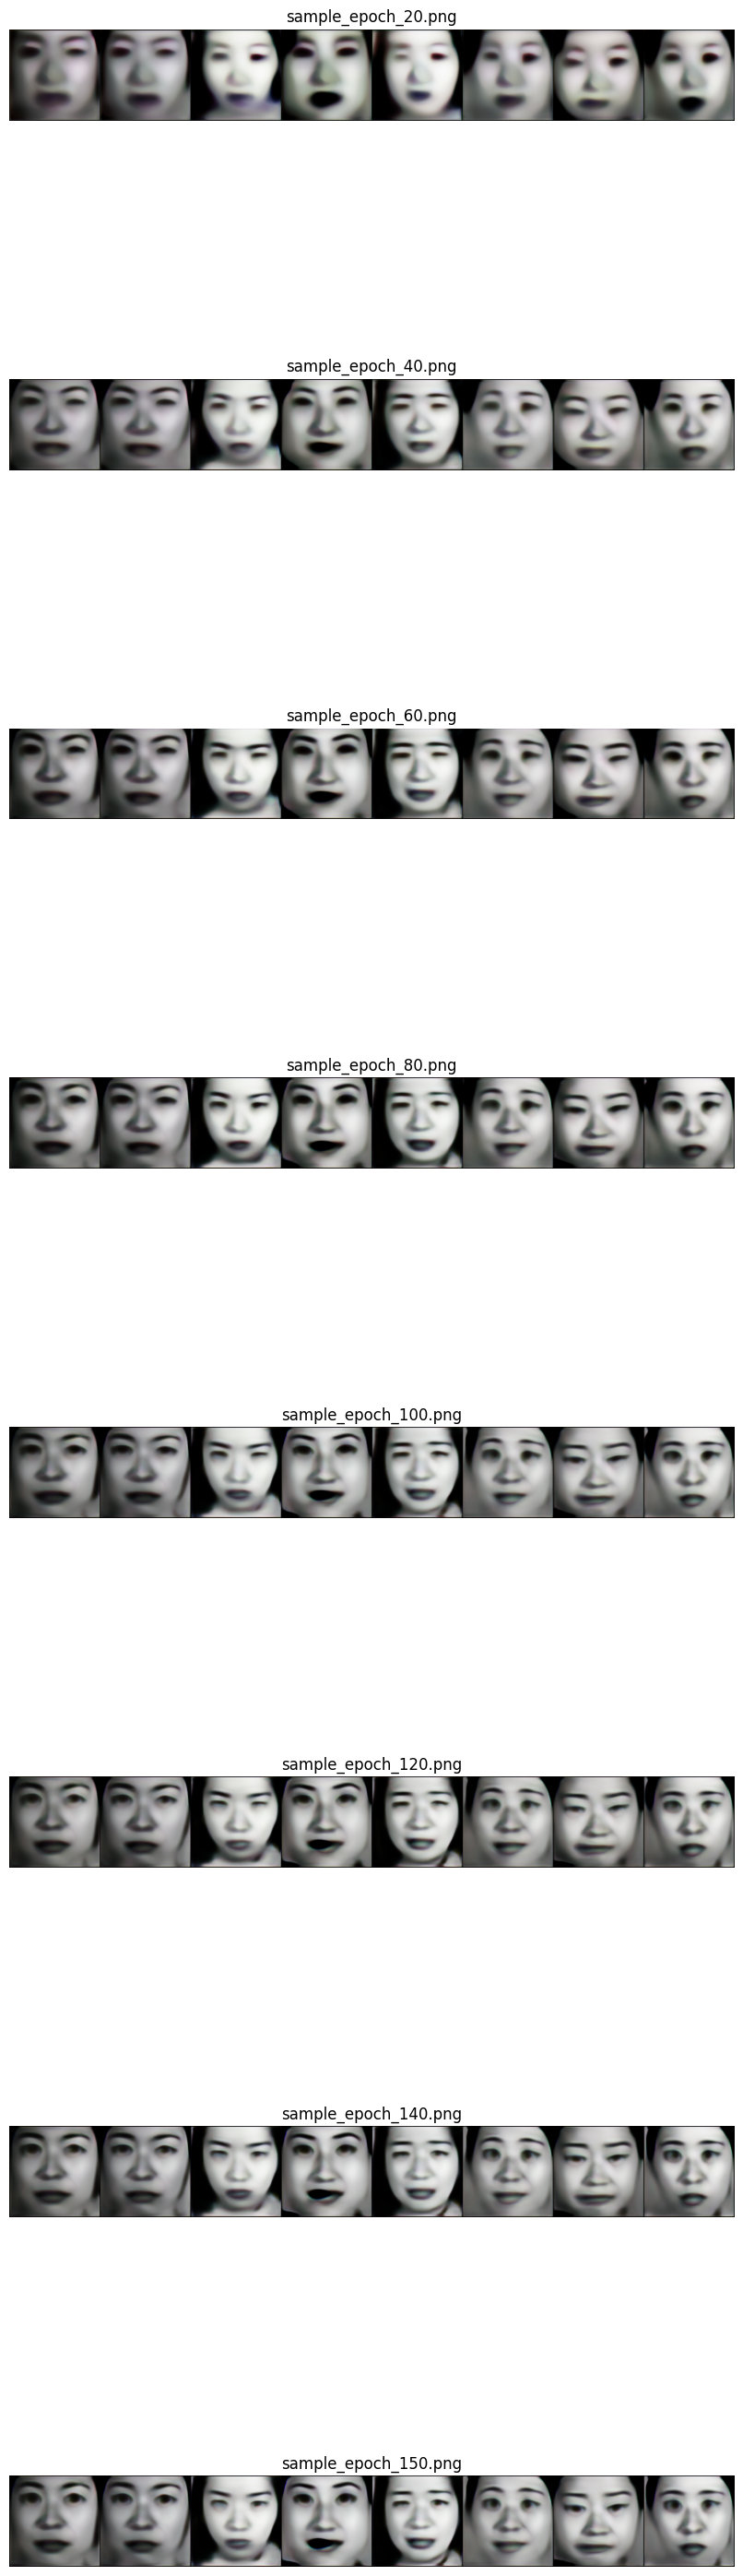

In [6]:
import cv2
import matplotlib.pyplot as plt
import glob
import os
import re

# --- 1. CONFIGURATION ---
SAMPLES_DIR = "/kaggle/working/gan_training_final_with_r1/samples"

# --- 2. FIND AND SORT ALL SAMPLE IMAGES ---
image_paths = glob.glob(os.path.join(SAMPLES_DIR, "sample_epoch_*.png"))

def get_epoch_from_path(path):
    # Extracts the number from a string like '..._epoch_150.png'
    match = re.search(r'epoch_(\d+)\.png', path)
    return int(match.group(1)) if match else -1

image_paths.sort(key=get_epoch_from_path)


# --- 3. VISUALIZE THE IMAGES IN A GRID (Updated for Vertical Layout) ---
if not image_paths:
    print(f"No sample images found in '{SAMPLES_DIR}'. Please check the path.")
else:
    print(f"Found {len(image_paths)} sample images. Displaying now...")
    
    num_images = len(image_paths)
    
    # --- THE FIX: Set the number of columns to 1 for a vertical layout ---
    num_cols = 1
    num_rows = num_images # Each image gets its own row
    
    # Adjust the figure size to be narrow and tall
    plt.figure(figsize=(8, num_rows * 4))
    
    for i, img_path in enumerate(image_paths):
        # Create a subplot for the current image
        plt.subplot(num_rows, num_cols, i + 1)
        
        # Load and convert the image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Show the image
        plt.imshow(image)
        plt.title(os.path.basename(img_path), fontsize=12)
        plt.axis("off")

    plt.tight_layout(pad=0.5) # Add a little padding
    plt.show()

--- Starting Stage 3.2: Encoder Training ---
Loaded and froze Generator weights from /kaggle/working/gan_training_final_with_r1/weights/gen_epoch_150.pth


Training Encoder: 100%|██████████| 14/14 [00:03<00:00,  3.76it/s, MSE_Loss=1.15]


Encoder Epoch [1/100] - Average MSE Loss: 1.2823


Training Encoder: 100%|██████████| 14/14 [00:03<00:00,  3.83it/s, MSE_Loss=1.04]


Encoder Epoch [2/100] - Average MSE Loss: 1.0470


...

Encoder Epoch [98/100] - Average MSE Loss: 0.4190


Training Encoder: 100%|██████████| 14/14 [00:03<00:00,  4.05it/s, MSE_Loss=0.414]


Encoder Epoch [99/100] - Average MSE Loss: 0.4198


Training Encoder: 100%|██████████| 14/14 [00:03<00:00,  4.06it/s, MSE_Loss=0.406]


Encoder Epoch [100/100] - Average MSE Loss: 0.4104
Saved Encoder checkpoint to /kaggle/working/encoder_training_results/encoder_epoch_100.pth
--- Encoder Training Finished ---
Generating final loss plot...


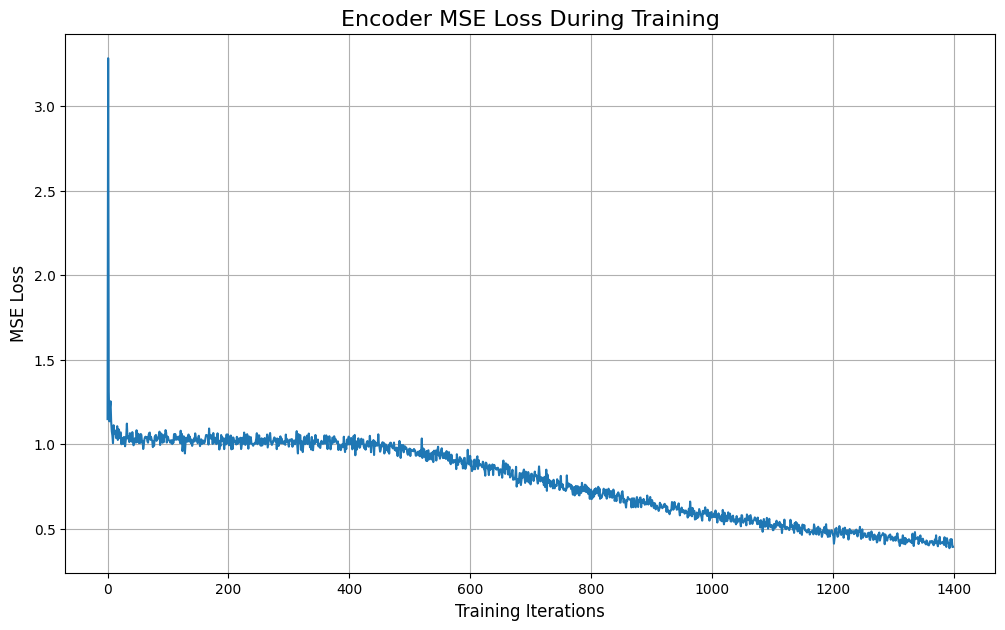

In [7]:
# --- IMPORTS for Encoder Training ---
from tqdm import tqdm
import torch
import torch.optim as optim
import torch.nn as nn
import os
import matplotlib.pyplot as plt # Import Matplotlib

# --- CONFIGURATION for Encoder Training ---
class Encoder_Config:
    # IMPORTANT: Update this path to your best GAN Generator weights from Stage 3.1
    GEN_WEIGHTS_PATH = "/kaggle/working/gan_training_final_with_r1/weights/gen_epoch_150.pth"
    
    # Path to save the new encoder weights
    SAVE_PATH = "/kaggle/working/encoder_training_results"
    
    LEARNING_RATE = 1e-4
    BATCH_SIZE = 32
    NUM_EPOCHS = 100

# --- 4. THE ENCODER TRAINING FUNCTION ---
def train_encoder_fn(gen, encoder, loader, opt_encoder, mse_loss, loss_list, fixed_landmark_map):
    loop = tqdm(loader, leave=True, desc="Training Encoder")
    
    for idx, _ in enumerate(loop): # We iterate to get a progress bar, but ignore the batch data
        
        batch_size = Encoder_Config.BATCH_SIZE
        # We repeat the first landmark map from our fixed batch to match the current batch size
        single_fixed_map = fixed_landmark_map[0].unsqueeze(0)
        batch_fixed_map = single_fixed_map.repeat(batch_size, 1, 1, 1)

        # Create the synthetic dataset
        z_true = torch.randn(batch_size, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
        
        with torch.no_grad():
            synthetic_face = gen(z_true, batch_fixed_map)
            
        # Train Encoder
        opt_encoder.zero_grad()
        z_predicted = encoder(synthetic_face)
        loss = mse_loss(z_predicted, z_true)
        loss.backward()
        opt_encoder.step()
        
        loss_list.append(loss.item())
        
        if idx % 50 == 0:
            loop.set_postfix(MSE_Loss=loss.item())

# --- 5. MAIN EXECUTION SCRIPT ---
def run_encoder_training():
    print("--- Starting Stage 3.2: Encoder Training ---")
    os.makedirs(Encoder_Config.SAVE_PATH, exist_ok=True)

    # Load and FREEZE the trained Generator
    gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(ModelConfig.DEVICE)
    gen.load_state_dict(torch.load(Encoder_Config.GEN_WEIGHTS_PATH, map_location=ModelConfig.DEVICE))
    gen.eval()
    for param in gen.parameters():
        param.requires_grad = False
    print(f"Loaded and froze Generator weights from {Encoder_Config.GEN_WEIGHTS_PATH}")
        
    # Initialize Encoder, Loss, Optimizer
    encoder = Encoder(ModelConfig.IMG_CHANNELS, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
    mse = nn.MSELoss()
    opt_encoder = optim.Adam(encoder.parameters(), lr=Encoder_Config.LEARNING_RATE)
    
    # This assumes 'gan_loader' is initialized from your DataLoader cell
    fixed_landmark_map = next(iter(gan_loader))['landmark_map'].to(ModelConfig.DEVICE)
    encoder_losses = []

    # The main training loop
    for epoch in range(Encoder_Config.NUM_EPOCHS):
        epoch_str = f"Encoder Epoch [{epoch+1}/{Encoder_Config.NUM_EPOCHS}]"
        train_encoder_fn(gen, encoder, gan_loader, opt_encoder, mse, encoder_losses, fixed_landmark_map)
        
        epoch_loss = np.mean(encoder_losses[-len(gan_loader):])
        print(f"{epoch_str} - Average MSE Loss: {epoch_loss:.4f}")

        if (epoch + 1) % 10 == 0 or epoch == Encoder_Config.NUM_EPOCHS - 1:
            save_path = os.path.join(Encoder_Config.SAVE_PATH, f"encoder_epoch_{epoch+1}.pth")
            torch.save(encoder.state_dict(), save_path)
            print(f"Saved Encoder checkpoint to {save_path}")
            
    print("--- Encoder Training Finished ---")
    
    # --- PLOTTING THE LOSSES ---
    print("Generating final loss plot...")
    plt.figure(figsize=(12, 7))
    plt.plot(encoder_losses)
    plt.title("Encoder MSE Loss During Training", fontsize=16)
    plt.xlabel("Training Iterations", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.grid(True)
    plt.savefig(os.path.join(Encoder_Config.SAVE_PATH, "encoder_loss_chart.png"))
    plt.show()
    
    return encoder

# --- To run this stage ---
if __name__ == '__main__':
    # This assumes all necessary classes and gan_loader are defined
    trained_encoder = run_encoder_training()

--- Loading all trained models ---
All models loaded successfully.

--- Starting Step 4: Identity-Preserving Optimization ---


Optimizing Identity Vector: 100%|██████████| 200/200 [00:20<00:00,  9.68it/s, identity_loss=0.171]


Optimization finished.

--- Generating Final Image ---


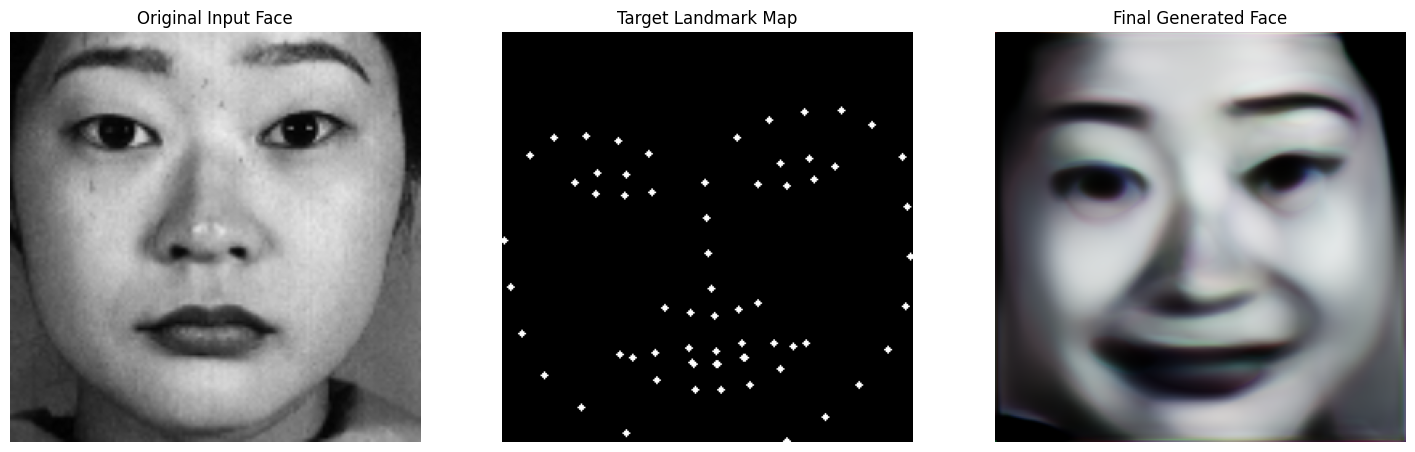

In [10]:

# --- 2. CONFIGURATION FOR INFERENCE ---
class InferenceConfig:
    # --- IMPORTANT: UPDATE THESE FOUR PATHS ---
    GEN_WEIGHTS_PATH = "/kaggle/working/gan_training_final_with_r1/weights/gen_epoch_150.pth"
    ENCODER_WEIGHTS_PATH = "/kaggle/working/encoder_training_results/encoder_epoch_100.pth"
    
    # The image you want to change
    INPUT_IMAGE_PATH = "/kaggle/working/processed_jaffe_gan/all_faces/KL_neutral_99.png"
    
    # The landmark map with the expression/pose you want to transfer
    TARGET_LANDMARK_MAP_PATH = "/kaggle/working/processed_jaffe_gan/all_landmark_maps/KL_happy_125.png"

    # Optimization parameters
    OPTIMIZATION_STEPS = 200
    OPTIMIZATION_LR = 0.01

# --- 3. LOAD ALL TRAINED MODELS ---
print("--- Loading all trained models ---")

# Load Generator
gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(ModelConfig.DEVICE)
gen.load_state_dict(torch.load(InferenceConfig.GEN_WEIGHTS_PATH, map_location=ModelConfig.DEVICE))
gen.eval()

# Load Encoder
encoder = Encoder(ModelConfig.IMG_CHANNELS, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
encoder.load_state_dict(torch.load(InferenceConfig.ENCODER_WEIGHTS_PATH, map_location=ModelConfig.DEVICE))
encoder.eval()

# Load Identity Loss Model
# This assumes the PyTorchIdentityLoss class using facenet-pytorch is defined
id_loss_fn = PyTorchIdentityLoss().to(ModelConfig.DEVICE)
id_loss_fn.eval()

print("All models loaded successfully.")

# --- 4. PREPARE INPUT TENSORS ---
# Define the same transformations used during training
inference_transform = A.Compose(
    [
        A.Resize(width=GAN_Config.IMG_SIZE, height=GAN_Config.IMG_SIZE), # Use GAN_Config
        A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], max_pixel_value=255.0),
        ToTensorV2(),
    ]
)

def preprocess_image(image_path):
    """Loads and preprocesses a single image for inference."""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    transformed_image = inference_transform(image=image)["image"]
    return transformed_image.unsqueeze(0).to(ModelConfig.DEVICE)

input_image_tensor = preprocess_image(InferenceConfig.INPUT_IMAGE_PATH)
target_landmark_tensor = preprocess_image(InferenceConfig.TARGET_LANDMARK_MAP_PATH)

# We also need the landmark map of the original input image for the optimization loop
# For this demo, we'll find it based on the input image's name
# In a real application, you would extract landmarks directly from the input image
base_filename = os.path.basename(InferenceConfig.INPUT_IMAGE_PATH)
original_landmark_path = f"/kaggle/working/processed_jaffe_gan/all_landmark_maps/{base_filename}"
original_landmark_tensor = preprocess_image(original_landmark_path)


# --- 5. RUN THE OPTIMIZATION LOOP ---
print("\n--- Starting Step 4: Identity-Preserving Optimization ---")

# Get the initial guess from the Encoder
with torch.no_grad():
    z_initial = encoder(input_image_tensor)

# Make this z vector a learnable parameter
z = z_initial.clone().detach().requires_grad_(True)

# Setup an optimizer for the z vector itself
optimizer_z = optim.Adam([z], lr=InferenceConfig.OPTIMIZATION_LR)

loop = tqdm(range(InferenceConfig.OPTIMIZATION_STEPS), desc="Optimizing Identity Vector")
for step in loop:
    optimizer_z.zero_grad()
    
    # Create a reconstruction of the original image
    reconstructed_face = gen(z, original_landmark_tensor)
    
    # Calculate the identity loss between the reconstruction and the original input
    loss = id_loss_fn(reconstructed_face, input_image_tensor)
    
    # Update the z vector to minimize the identity loss
    loss.backward()
    optimizer_z.step()
    
    if step % 20 == 0:
        loop.set_postfix(identity_loss=loss.item())

z_optimized = z.detach().clone()
print("Optimization finished.")

# --- 6. FINAL IMAGE GENERATION AND VISUALIZATION ---
print("\n--- Generating Final Image ---")
with torch.no_grad():
    final_image = gen(z_optimized, target_landmark_tensor)

def visualize_final_result(original, target_landmarks, final):
    def to_displayable_img(tensor):
        img = tensor.squeeze(0).cpu().detach()
        img = img * 0.5 + 0.5 # Denormalize
        img = img.permute(1, 2, 0).numpy()
        return np.clip(img, 0, 1)

    original_img = to_displayable_img(original)
    landmark_img = to_displayable_img(target_landmarks)
    final_img = to_displayable_img(final)

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Input Face")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(landmark_img)
    plt.title("Target Landmark Map")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(final_img)
    plt.title("Final Generated Face")
    plt.axis('off')
    plt.show()

visualize_final_result(input_image_tensor, target_landmark_tensor, final_image)

In [12]:
# --- 1. INSTALL THE FID LIBRARY ---
!pip install -q torch-fidelity

import glob
from torch_fidelity import calculate_metrics

# You must have your Generator, ModelConfig, and gan_loader defined in previous cells

# --- 3. CONFIGURATION ---
class FidConfig:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    GEN_WEIGHTS_PATH = "/kaggle/working/gan_training_final_with_r1/weights/gen_epoch_150.pth"
    REAL_IMAGES_PATH = "/kaggle/working/processed_jaffe_gan/all_faces"
    FAKE_IMAGES_PATH = "/kaggle/working/fid_generated_images"
    NUM_IMAGES_TO_GENERATE = 1000
    BATCH_SIZE = 16

# --- 4. FUNCTION TO GENERATE IMAGES (No changes needed) ---
def generate_images_for_fid(gen_weights_path, output_path, num_images):
    print(f"--- Generating {num_images} images for FID evaluation ---")
    os.makedirs(output_path, exist_ok=True)
    gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(FidConfig.DEVICE)
    gen.load_state_dict(torch.load(gen_weights_path, map_location=FidConfig.DEVICE))
    gen.eval()
    fixed_landmarks = next(iter(gan_loader))['landmark_map'].to(FidConfig.DEVICE)
    single_fixed_map = fixed_landmarks[0].unsqueeze(0)
    generated_count = 0
    with torch.no_grad():
        while generated_count < num_images:
            batch_size = min(FidConfig.BATCH_SIZE, num_images - generated_count)
            if batch_size <= 0: break
            z = torch.randn(batch_size, ModelConfig.Z_DIM).to(FidConfig.DEVICE)
            batch_fixed_map = single_fixed_map.repeat(batch_size, 1, 1, 1)
            fake_images = gen(z, batch_fixed_map)
            for i in range(fake_images.shape[0]):
                img_tensor = fake_images[i] * 0.5 + 0.5
                save_path = os.path.join(output_path, f"fake_image_{generated_count + i}.png")
                torchvision.utils.save_image(img_tensor, save_path)
            generated_count += batch_size
            print(f"Generated {generated_count}/{num_images} images...")
    print(f"Image generation complete. Images saved to {output_path}")

# --- 5. FUNCTION TO CALCULATE METRICS (Updated) ---
def calculate_gan_metrics(real_path, fake_path):
    """Calculates FID and KID between two directories of images."""
    print("\n--- Calculating Metrics (FID, KID) ---")
    print("This may take a few minutes...")

    # Determine a valid subset size for KID
    num_real_images = len(glob.glob(os.path.join(real_path, "*.png")))
    num_fake_images = len(glob.glob(os.path.join(fake_path, "*.png")))
    subset_size = min(num_real_images, num_fake_images)
    print(f"Using subset size of {subset_size} for KID calculation.")
    
    metrics_dict = calculate_metrics(
        input1=real_path,
        input2=fake_path,
        cuda=True,
        isc=False, # Set to False
        fid=True,
        kid=True,
        kid_subset_size=subset_size,
        verbose=False,
    )
    
    # Extract and print the relevant scores
    fid_score = metrics_dict['frechet_inception_distance']
    kid_score = metrics_dict['kernel_inception_distance_mean'] * 100
    
    print("\n--- Evaluation Results ---")
    print(f"Fréchet Inception Distance (FID): {fid_score:.4f} (Lower is better)")
    print(f"Kernel Inception Distance (KID): {kid_score:.4f} (Lower is better)")
    
    return metrics_dict

# --- 6. EXECUTION ---
if __name__ == '__main__':
    # Step 1: Generate the fake images
    generate_images_for_fid(FidConfig.GEN_WEIGHTS_PATH, FidConfig.FAKE_IMAGES_PATH, FidConfig.NUM_IMAGES_TO_GENERATE)
    
    # Step 2: Calculate the metrics
    gan_metrics = calculate_gan_metrics(FidConfig.REAL_IMAGES_PATH, FidConfig.FAKE_IMAGES_PATH)

--- Generating 1000 images for FID evaluation ---
Generated 16/1000 images...
Generated 32/1000 images...
Generated 48/1000 images...
Generated 64/1000 images...
Generated 80/1000 images...
Generated 96/1000 images...
Generated 112/1000 images...
Generated 128/1000 images...
Generated 144/1000 images...
Generated 160/1000 images...
Generated 176/1000 images...
Generated 192/1000 images...
Generated 208/1000 images...
Generated 224/1000 images...
Generated 240/1000 images...
Generated 256/1000 images...
Generated 272/1000 images...
Generated 288/1000 images...
Generated 304/1000 images...
Generated 320/1000 images...
Generated 336/1000 images...
Generated 352/1000 images...
Generated 368/1000 images...
Generated 384/1000 images...
Generated 400/1000 images...
Generated 416/1000 images...
Generated 432/1000 images...
Generated 448/1000 images...
Generated 464/1000 images...
Generated 480/1000 images...
Generated 496/1000 images...
Generated 512/1000 images...
Generated 528/1000 images...

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 185MB/s]
/usr/local/lib/python3.11/dist-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)



--- Evaluation Results ---
Fréchet Inception Distance (FID): 311.6886 (Lower is better)
Kernel Inception Distance (KID): 52.9317 (Lower is better)


Loading InceptionV3 model...


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 148MB/s]  
Extracting Features: 100%|██████████| 200/200 [00:04<00:00, 49.45it/s]



Performing t-SNE... (This may take a moment)
Plotting results...


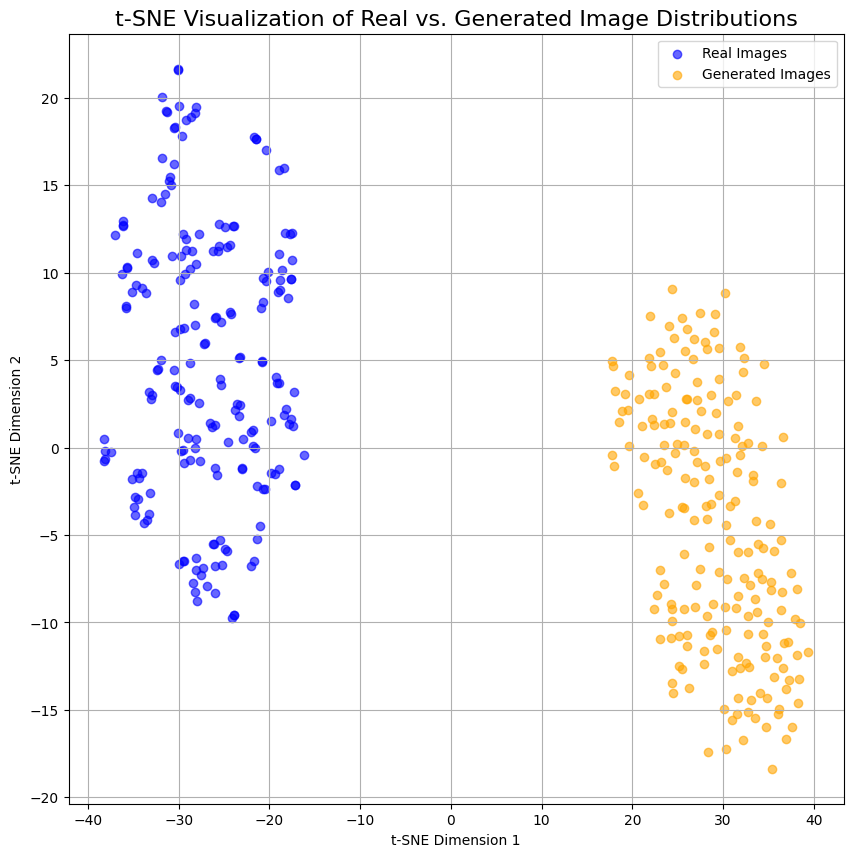

In [13]:
# --- 1. IMPORTS ---
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
from tqdm import tqdm

# --- 2. CONFIGURATION ---
class VizConfig:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Paths to your image folders
    REAL_IMAGES_PATH = "/kaggle/working/processed_jaffe_gan/all_faces"
    FAKE_IMAGES_PATH = "/kaggle/working/fid_generated_images"

    # Number of images to use for the plot (using too many is slow)
    NUM_SAMPLES = 200 # 200 real and 200 fake

# --- 3. FEATURE EXTRACTION FUNCTION ---
def get_inception_features(image_paths, model, transform):
    """Extracts features from a list of images using a pre-trained InceptionV3 model."""
    features = []
    
    for img_path in tqdm(image_paths, desc="Extracting Features"):
        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(VizConfig.DEVICE)
            
            with torch.no_grad():
                feature_vector = model(img_tensor)
                
            features.append(feature_vector.cpu().numpy().flatten())
        except Exception as e:
            print(f"Skipping image {img_path} due to error: {e}")
            
    return np.array(features)

# --- 4. MAIN EXECUTION ---
if __name__ == '__main__':
    # --- Load pre-trained InceptionV3 model ---
    print("Loading InceptionV3 model...")
    inception_model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, transform_input=False)
    # Remove the final classification layer to get the feature extractor
    inception_model.fc = torch.nn.Identity()
    inception_model = inception_model.to(VizConfig.DEVICE)
    inception_model.eval()

    # --- Define image transformations for InceptionV3 ---
    # InceptionV3 expects 299x299 images with specific normalization
    inception_transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # --- Get image paths ---
    real_image_paths = glob.glob(os.path.join(VizConfig.REAL_IMAGES_PATH, "*.png"))
    fake_image_paths = glob.glob(os.path.join(VizConfig.FAKE_IMAGES_PATH, "*.png"))

    # Take a random sample of images
    real_samples = np.random.choice(real_image_paths, VizConfig.NUM_SAMPLES, replace=False)
    fake_samples = np.random.choice(fake_image_paths, VizConfig.NUM_SAMPLES, replace=False)

    # --- Extract features ---
    real_features = get_inception_features(real_samples, inception_model, inception_transform)
    fake_features = get_inception_features(fake_samples, inception_model, inception_transform)

    # --- Perform t-SNE ---
    print("\nPerforming t-SNE... (This may take a moment)")
    combined_features = np.vstack([real_features, fake_features])
    
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
    tsne_results = tsne.fit_transform(combined_features)

    # --- Plot the results ---
    print("Plotting results...")
    plt.figure(figsize=(10, 10))
    
    num_real = len(real_features)
    # Plot real image features
    plt.scatter(tsne_results[:num_real, 0], tsne_results[:num_real, 1], c='blue', alpha=0.6, label='Real Images')
    # Plot fake image features
    plt.scatter(tsne_results[num_real:, 0], tsne_results[num_real:, 1], c='orange', alpha=0.6, label='Generated Images')
    
    plt.title("t-SNE Visualization of Real vs. Generated Image Distributions", fontsize=16)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.grid(True)
    plt.show()

--- Loading all trained models for comparison ---
All models loaded.

--- Starting Ablation Study: Baseline vs. Full Method ---


Processing Test Images: 100%|██████████| 10/10 [03:43<00:00, 22.31s/it]


--- Visualizing Comparison Results ---


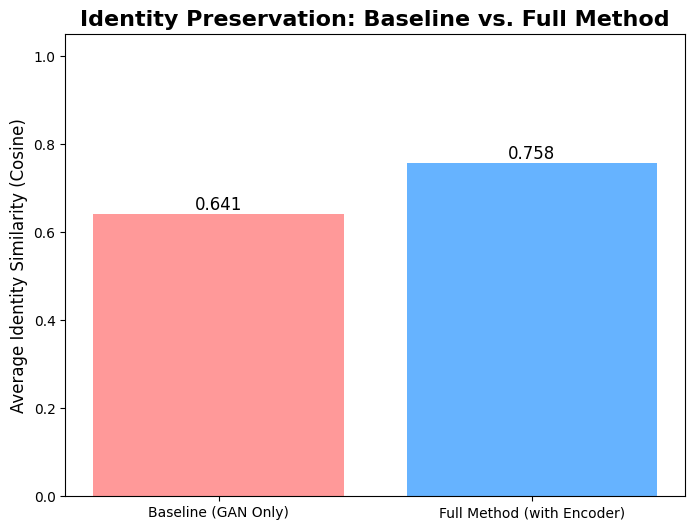

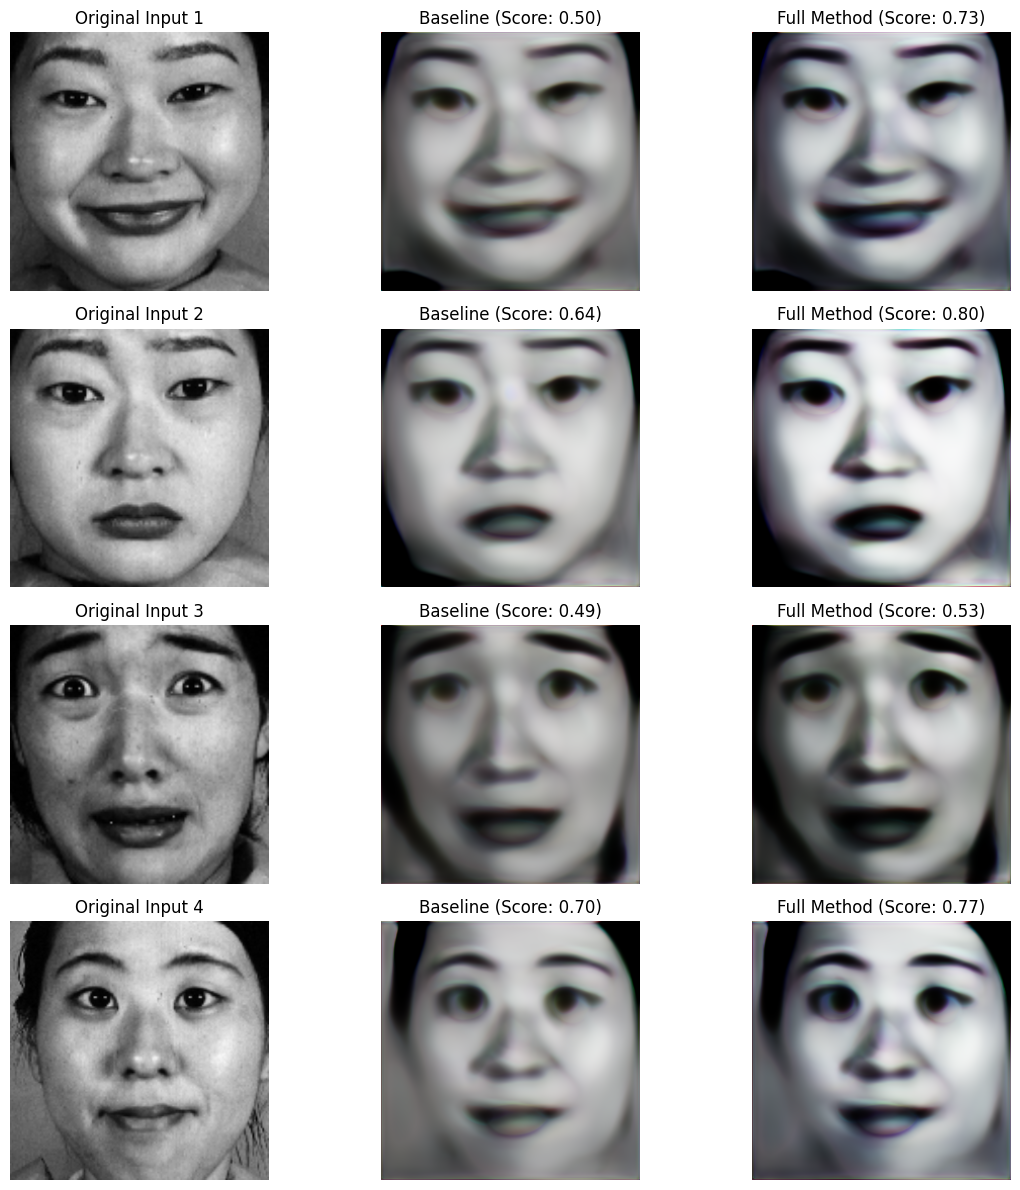

In [14]:
# --- 1. IMPORTS ---
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import os
import glob
import random

# Ensure all your model classes (Generator, Encoder, PyTorchIdentityLoss)
# and Config classes (ModelConfig, GAN_Config) are defined in previous cells.

# --- 2. CONFIGURATION FOR THE COMPARISON ---
class ComparisonConfig:
    # --- IMPORTANT: UPDATE THESE PATHS ---
    GEN_WEIGHTS_PATH = "/kaggle/working/gan_training_final_with_r1/weights/gen_epoch_150.pth"
    ENCODER_WEIGHTS_PATH = "/kaggle/working/encoder_training_results/encoder_epoch_100.pth"
    
    # --- Paths to the data directories ---
    FACES_DIR = "/kaggle/working/processed_jaffe_gan/all_faces/"
    LANDMARKS_DIR = "/kaggle/working/processed_jaffe_gan/all_landmark_maps/"
    
    # --- Parameters for the optimization loop ---
    OPTIMIZATION_STEPS = 200
    OPTIMIZATION_LR = 0.01
    
    # --- Number of images to test ---
    NUM_TEST_IMAGES = 10

# --- 3. LOAD ALL MODELS ---
print("--- Loading all trained models for comparison ---")
# Load Generator
gen = Generator(ModelConfig.Z_DIM, ModelConfig.LANDMARK_CHANNELS, ModelConfig.IMG_CHANNELS, ModelConfig.GEN_FEATURES).to(ModelConfig.DEVICE)
gen.load_state_dict(torch.load(ComparisonConfig.GEN_WEIGHTS_PATH, map_location=ModelConfig.DEVICE))
gen.eval()

# Load Encoder
encoder = Encoder(ModelConfig.IMG_CHANNELS, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
encoder.load_state_dict(torch.load(ComparisonConfig.ENCODER_WEIGHTS_PATH, map_location=ModelConfig.DEVICE))
encoder.eval()

# Load Identity Loss Model (for calculating similarity)
id_loss_fn = PyTorchIdentityLoss().to(ModelConfig.DEVICE)
id_loss_fn.eval()
print("All models loaded.")

# --- 4. HELPER FUNCTIONS ---
# Define the same transformations used during training
inference_transform = A.Compose(
    [
        # --- CORRECTED: Use GAN_Config for IMG_SIZE ---
        A.Resize(width=GAN_Config.IMG_SIZE, height=GAN_Config.IMG_SIZE),
        A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], max_pixel_value=255.0),
        ToTensorV2(),
    ]
)

def preprocess_image(image_path):
    """Loads and preprocesses a single image for inference."""
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not read image at {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    transformed_image = inference_transform(image=image)["image"]
    return transformed_image.unsqueeze(0).to(ModelConfig.DEVICE)

def calculate_identity_similarity(img1_tensor, img2_tensor):
    """Calculates the cosine similarity between two image tensors."""
    with torch.no_grad():
        # The id_loss_fn calculates 1 - similarity, so we reverse it
        similarity = 1 - id_loss_fn(img1_tensor, img2_tensor).item()
    return similarity

# --- 5. MAIN COMPARISON SCRIPT ---
def run_comparison():
    print("\n--- Starting Ablation Study: Baseline vs. Full Method ---")
    
    all_face_paths = glob.glob(os.path.join(ComparisonConfig.FACES_DIR, "*.png"))
    if not all_face_paths:
        print(f"Error: No images found in {ComparisonConfig.FACES_DIR}. Please check the path.")
        return pd.DataFrame()
        
    test_image_paths = random.sample(all_face_paths, min(len(all_face_paths), ComparisonConfig.NUM_TEST_IMAGES))
    
    results = []

    for input_path in tqdm(test_image_paths, desc="Processing Test Images"):
        base_filename = os.path.basename(input_path)
        target_landmark_path = os.path.join(ComparisonConfig.LANDMARKS_DIR, base_filename)
        
        input_tensor = preprocess_image(input_path)
        target_landmark_tensor = preprocess_image(target_landmark_path)
        
        if input_tensor is None or target_landmark_tensor is None:
            continue

        # --- Method A: Baseline (GAN with random z) ---
        with torch.no_grad():
            random_z = torch.randn(1, ModelConfig.Z_DIM).to(ModelConfig.DEVICE)
            baseline_image = gen(random_z, target_landmark_tensor)
        
        # --- Method B: Full Method (Encoder + Optimization) ---
        with torch.no_grad():
            z_initial = encoder(input_tensor)
        
        z = z_initial.clone().detach().requires_grad_(True)
        optimizer_z = optim.Adam([z], lr=ComparisonConfig.OPTIMIZATION_LR)
        
        for _ in range(ComparisonConfig.OPTIMIZATION_STEPS):
            optimizer_z.zero_grad()
            reconstructed = gen(z, target_landmark_tensor)
            loss = id_loss_fn(reconstructed, input_tensor)
            loss.backward()
            optimizer_z.step()
        
        with torch.no_grad():
            full_method_image = gen(z.detach(), target_landmark_tensor)
            
        # --- Calculate Metrics ---
        baseline_similarity = calculate_identity_similarity(input_tensor, baseline_image)
        full_method_similarity = calculate_identity_similarity(input_tensor, full_method_image)
        
        results.append({
            "input_path": input_path,
            "baseline_similarity": baseline_similarity,
            "full_method_similarity": full_method_similarity,
            "baseline_image": baseline_image,
            "full_method_image": full_method_image
        })

    return pd.DataFrame(results)

# --- 6. VISUALIZE THE RESULTS ---
def visualize_comparison(results_df):
    if results_df.empty:
        print("No results to visualize.")
        return
        
    print("\n--- Visualizing Comparison Results ---")
    
    # --- Quantitative Plot (Bar Chart) ---
    avg_baseline = results_df['baseline_similarity'].mean()
    avg_full = results_df['full_method_similarity'].mean()
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(['Baseline (GAN Only)', 'Full Method (with Encoder)'], [avg_baseline, avg_full], color=['#ff9999', '#66b3ff'])
    plt.ylabel('Average Identity Similarity (Cosine)', fontsize=12)
    plt.title('Identity Preservation: Baseline vs. Full Method', fontsize=16, fontweight='bold')
    plt.ylim(0, 1.05)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', va='bottom', ha='center', fontsize=12)
    plt.show()

    # --- Qualitative Plot (Image Grid) ---
    num_visual_samples = min(4, len(results_df))
    plt.figure(figsize=(12, 3 * num_visual_samples))
    
    for i in range(num_visual_samples):
        row = results_df.iloc[i]
        
        def to_img(tensor):
            img = tensor.squeeze(0).cpu().detach() * 0.5 + 0.5
            return img.permute(1, 2, 0).numpy()

        original_img = to_img(preprocess_image(row['input_path']))
        baseline_img = to_img(row['baseline_image'])
        full_method_img = to_img(row['full_method_image'])
        
        plt.subplot(num_visual_samples, 3, i * 3 + 1)
        plt.imshow(original_img)
        plt.title(f"Original Input {i+1}")
        plt.axis('off')
        
        plt.subplot(num_visual_samples, 3, i * 3 + 2)
        plt.imshow(baseline_img)
        plt.title(f"Baseline (Score: {row['baseline_similarity']:.2f})")
        plt.axis('off')
        
        plt.subplot(num_visual_samples, 3, i * 3 + 3)
        plt.imshow(full_method_img)
        plt.title(f"Full Method (Score: {row['full_method_similarity']:.2f})")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- Run the comparison ---
if __name__ == '__main__':
    comparison_results = run_comparison()
    if not comparison_results.empty:
        visualize_comparison(comparison_results)